## Proyecto prueba analizando GGAL

In [2]:
# pip install yfinance pandas matplotlib PyWavelets numpy statsmodels

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import pywt                         
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
import matplotlib.dates as mdates

# Esto es necesario para asegurar que las fechas se manejen correctamente tras la descarga
import warnings
warnings.filterwarnings('ignore')

In [4]:
tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']

start = '2008-01-01'
end = '2025-01-01'

raw = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False
)

data = raw['Close']
aperturas = raw['Open']
volumen = raw['Volume']

[*********************100%***********************]  8 of 8 completed


In [5]:
ticker = 'GGAL'

# Aislamos las series de apertura y cierre solo para GGAL
open_ticker = aperturas[ticker].copy()
close_ticker = data[ticker].copy()

# Quitamos la timezone del índice de fechas
open_ticker.index = open_ticker.index.tz_localize(None)
close_ticker.index = close_ticker.index.tz_localize(None)


# variación % entre el cierre del día anterior y la apertura de hoy
gap_overnight = open_ticker / close_ticker.shift(1) - 1
gap_overnight.name = 'gap_overnight'

# Ejemplo: cierre ayer = 100, apertura hoy = 102
# gap = 102/100 - 1 = 0.02 (2% de salto "fuera de horario de mercado")

In [6]:
# Armamos un DataFrame prolijo con apertura, cierre anterior y el gap
df_gaps = pd.DataFrame({
    'open': open_ticker,
    'close_anterior': close_ticker.shift(1),
    'gap_overnight': gap_overnight
}).dropna()  # eliminamos la primera fila (NaN por el shift)

# Umbral para considerar un gap como "grande" (1%)
umbral = 0.01

# Cantidad total de ruedas (días) con datos válidos
total_dias = len(df_gaps)

# Cuántos días el gap fue positivo / negativo (sin importar magnitud)
gaps_positivos = (df_gaps['gap_overnight'] > 0).sum()
gaps_negativos = (df_gaps['gap_overnight'] < 0).sum()

# Cuántos días el gap (en valor absoluto) superó el umbral, sin importar signo
gaps_grandes = (df_gaps['gap_overnight'].abs() >= umbral).sum()

# Gaps grandes positivos (subas fuertes en la apertura)
gaps_grandes_positivos = (df_gaps['gap_overnight'] >= umbral).sum()

# Gaps grandes negativos (bajas fuertes en la apertura)
gaps_grandes_negativos = (df_gaps['gap_overnight'] <= -umbral).sum()

# Impresión de resultados
print('Total de ruedas analizadas:', total_dias)
print('Gaps positivos:', gaps_positivos)
print('Gaps negativos:', gaps_negativos)
print(f'Gaps mayores a +/- {umbral:.0%}:', gaps_grandes)
print(f'Gaps positivos mayores a {umbral:.0%}:', gaps_grandes_positivos)
print(f'Gaps negativos menores a -{umbral:.0%}:', gaps_grandes_negativos)
print()

# Porcentaje de días con gap grande sobre el total de ruedas
print('Porcentaje de gaps grandes:', gaps_grandes / total_dias)

Total de ruedas analizadas: 4278
Gaps positivos: 2208
Gaps negativos: 1819
Gaps mayores a +/- 1%: 1535
Gaps positivos mayores a 1%: 874
Gaps negativos menores a -1%: 661

Porcentaje de gaps grandes: 0.3588125292192613


In [7]:
df_gaps['gap_pct'] = df_gaps['gap_overnight'] * 100

# Ordenamos el DataFrame por la magnitud del gap, sin importar el signo
df_gaps.sort_values(
    'gap_overnight',   # columna por la que ordenamos
    key=abs,           # aplicamos valor absoluto ANTES de ordenar
                        # así un gap de -5% queda "más grande" que uno de +2%
    ascending=False     
).head(5)              

,open,close_anterior,gap_overnight,gap_pct
Date,,,,
2019-08-12,19.309999,38.169998,-0.494105,-49.410531
2008-12-01,1.460000,1.900000,-0.231579,-23.157892
2023-11-20,14.790000,12.500000,0.183200,18.320000
2015-10-26,25.000000,21.299999,0.173709,17.370896
2020-03-16,7.720000,9.210000,-0.161781,-16.178070


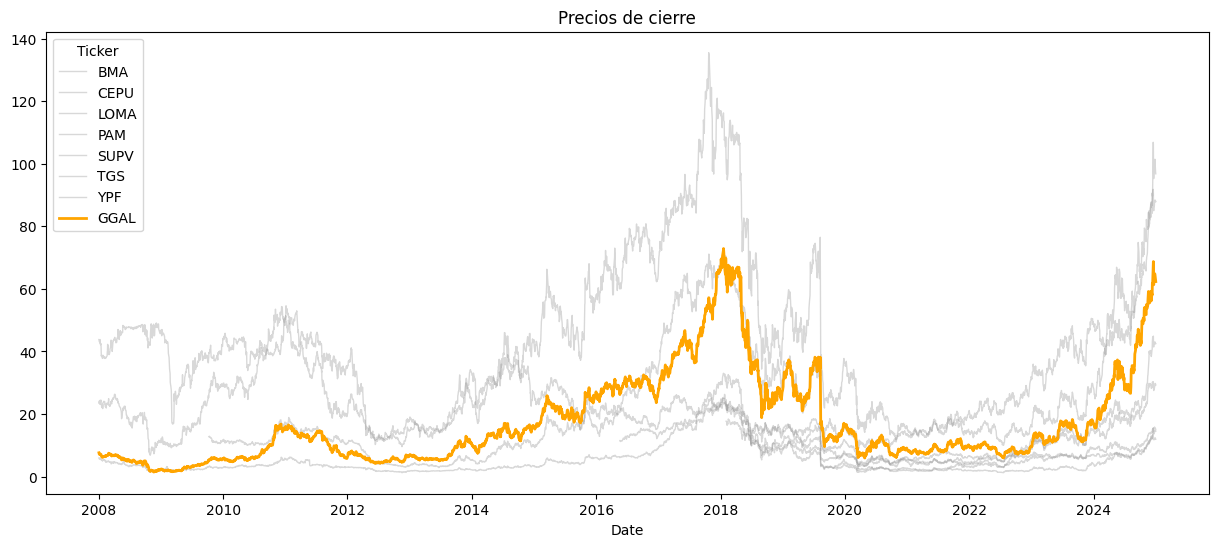

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

# Graficamos primero todas las acciones "de fondo" en gris y con baja opacidad
for col in data.columns:
    if col != 'GGAL':
        ax.plot(data.index, data[col], color='gray', alpha=0.3, linewidth=1, label=col)

# Graficamos GGAL al final (queda por encima) con color propio y opacidad completa
ax.plot(data.index, data['GGAL'], color='orange', alpha=1.0, linewidth=2, label='GGAL')

ax.set_title('Precios de cierre')
ax.set_xlabel('Date')
ax.legend(title='Ticker')
plt.show()

## Filtro de Media Movil (MA30 MA90)

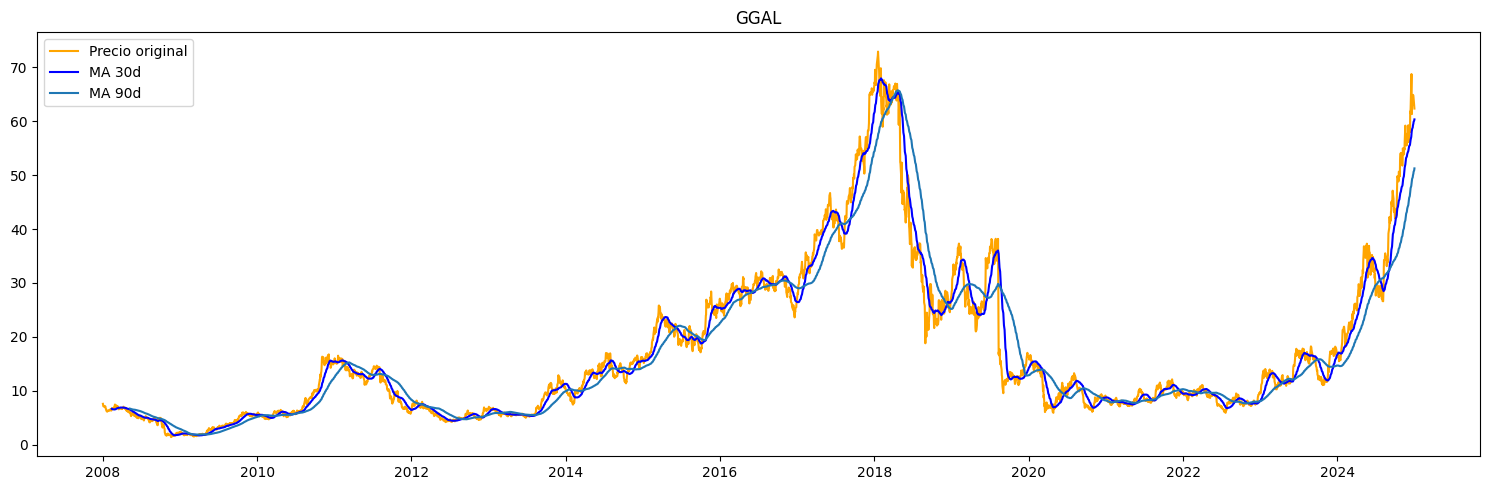

In [25]:
fig, ax = plt.subplots(figsize=(15, 5))

ventanas = [30, 90]  # 1 mes y 3 meses

# Precio original de GGAL en naranja, semi-transparente
ax.plot(data.index, data['GGAL'], color='orange', alpha=1, label='Precio original')

# Calculamos y graficamos cada media móvil
for ventana in ventanas:
    ma = data['GGAL'].rolling(window=ventana).mean()
    color = 'steelblue' if ventana == 90 else None
    color = 'blue' if ventana == 30 else None
    ax.plot(data.index, ma, color=color, label=f'MA {ventana}d')

ax.set_title('GGAL')
ax.legend()

plt.tight_layout()
plt.show()

Notamos que la MA90 tiende a ser una función más suave que la MA30, esto es porque se mueve más lento.

Notar: Cuando más agrandamos el gap de la MA, más suave se vuelve la curva y menor es el ruido pero a costa de un mayor retraso en reaccionar a cambios reales de tendencia.

## Transformada de Fourier (FFT)

Veamos que pasa si aplicamos la Transformada de Fourier al precio de Galicia

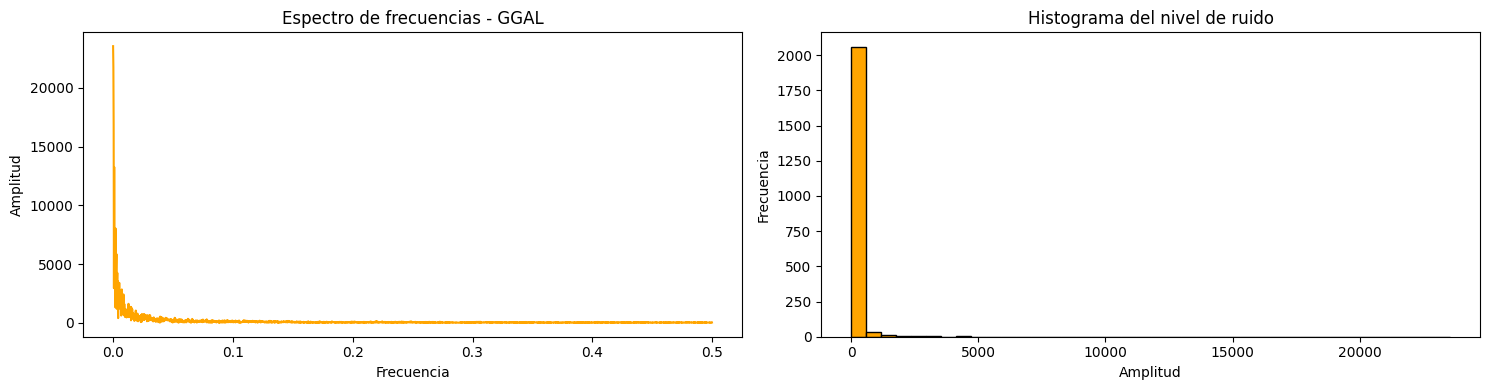

In [10]:
import numpy as np

ticker = 'GGAL'
precios = data[ticker].dropna().values

# Aplicamos FFT
fft = np.fft.fft(precios)
frecuencias = np.fft.fftfreq(len(precios))

# Magnitud de las componentes espectrales (excluimos la frecuencia 0)
nivel_ruido = np.abs(fft[1:len(fft)//2])

# Graficamos el espectro de frecuencias y el histograma del nivel de ruido
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(
    frecuencias[1:len(frecuencias)//2],
    nivel_ruido,
    color='orange'
)
axes[0].set_title(f'Espectro de frecuencias - {ticker}')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Amplitud')

axes[1].hist(nivel_ruido, bins=40, color='orange', edgecolor='black')
axes[1].set_title('Histograma del nivel de ruido')
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Horrible. Viendo este grafico, nuestra primera intuicion es que el precio de GGAL **no es una serie estacionaria**. 

Confirmemoslo


---

## Es GGAL Estacionaria? 

### Diagnóstico combinado ADF + KPSS

Recordemos 

| ADF p-value      | KPSS p-value      | Diagnóstico       |
|-------------------|---------------------|--------------------|
| p < 0.05             | p ≥ 0.05                | **Estacionaria**     |
| p < 0.05             | p < 0.05                | **Indefinida**        |
| p ≥ 0.05             | p ≥ 0.05                | **Indefinida**        |
| p ≥ 0.05             | p < 0.05                | **No estacionaria**   |

In [26]:
def test_estacionariedad(serie, nombre='serie', regression_kpss='c'):
    adf_p = adfuller(serie, autolag='AIC')[1]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')  # KPSS suele tirar warning por interpolación de p-value
        kpss_p = kpss(serie, regression=regression_kpss, nlags='auto')[1]

    print(f'{nombre}:')
    print(f'  ADF p-value:  {adf_p:.4f}')
    print(f'  KPSS p-value: {kpss_p:.4f}')
    print()

    return adf_p, kpss_p


resultados_estacionariedad = {}

for ticker in tickers:
    precios = data[ticker].dropna()
    adf_p, kpss_p = test_estacionariedad(precios, nombre=f'Precio {ticker}')
    resultados_estacionariedad[ticker] = {'adf_p': adf_p, 'kpss_p': kpss_p}

Precio YPF:
  ADF p-value:  0.3361
  KPSS p-value: 0.0100

Precio GGAL:
  ADF p-value:  0.8021
  KPSS p-value: 0.0100

Precio BMA:
  ADF p-value:  0.6655
  KPSS p-value: 0.0100

Precio SUPV:
  ADF p-value:  0.5915
  KPSS p-value: 0.0100

Precio LOMA:
  ADF p-value:  0.0461
  KPSS p-value: 0.0100

Precio CEPU:
  ADF p-value:  0.3392
  KPSS p-value: 0.0100

Precio PAM:
  ADF p-value:  0.9915
  KPSS p-value: 0.0100

Precio TGS:
  ADF p-value:  0.9926
  KPSS p-value: 0.0100



In [30]:
# Si ADF p-value >= 0.05 y KPSS p-value < 0.05 entonces la serie es NO ESTACIONARIA
# Si ADF p-value < 0.05 y KPSS p-value >= 0.05 entonces la serie es ESTACIONARIA
def diagnostico(adf_p, kpss_p, alpha=0.05):
    adf_estacionaria = adf_p < alpha
    kpss_estacionaria = kpss_p >= alpha

    if adf_estacionaria and kpss_estacionaria:
        return 'Estacionaria'
    elif not adf_estacionaria and not kpss_estacionaria:
        return 'No estacionaria'
    elif not adf_estacionaria and kpss_estacionaria:
        return 'Indefinida (posible tendencia - trend-stationary)'
    else:
        return 'Indefinida (posible necesidad de diferenciar)'

In [31]:
adf_p, kpss_p = test_estacionariedad(precios.values, nombre='Precio GGAL')
print('Diagnóstico:', diagnostico(adf_p, kpss_p))
print()

Precio GGAL:
  ADF p-value:  0.9926
  KPSS p-value: 0.0100

Diagnóstico: No estacionaria



Luego, GGAL **no es estacionaria** 

La FFT asume que la señal es estacionaria, estamos entonces implementando una transformada incorrecta. 

Debemos implementar otra transformada que pueda usarse con series no estacionarias.

## Algoritmo Piramidal de Mallat (para GGAL)

Esta transformada no necesita que la serie sea estacionaria.

In [14]:
# Aislamos el precio de cierre de GGAL.

ticker = 'GGAL'

precios = data[ticker].dropna()
fechas = precios.index
precios_vals = precios.values

Aplicamos wavedec, que ejecuta el algoritmo piramidal: descompone la señal en un componente de aproximación (tendencia gruesa) y varios componentes de detalle (fluctuaciones en distintas escalas temporales).

La metodologia utilizada por Mallat es la siguiente:
1. Toma la señal actual (al principio, el precio original).
2. La pasa por un filtro pasa-bajos → obtiene la aproximación de ese paso (versión suavizada).
3. La pasa por un filtro pasa-altos → obtiene el detalle de ese paso (lo que se "perdió" al suavizar, es decir, las fluctuaciones de esa escala).
4. Hace downsampling (se queda con la mitad de los puntos) en ambos resultados.
5. Guarda el detalle, y repite el proceso tomando la aproximación como nueva "señal actual" para el siguiente nivel.

Diagramita hecho con Claude sobre como se comporta el Algoritmo piramidal de Mallat

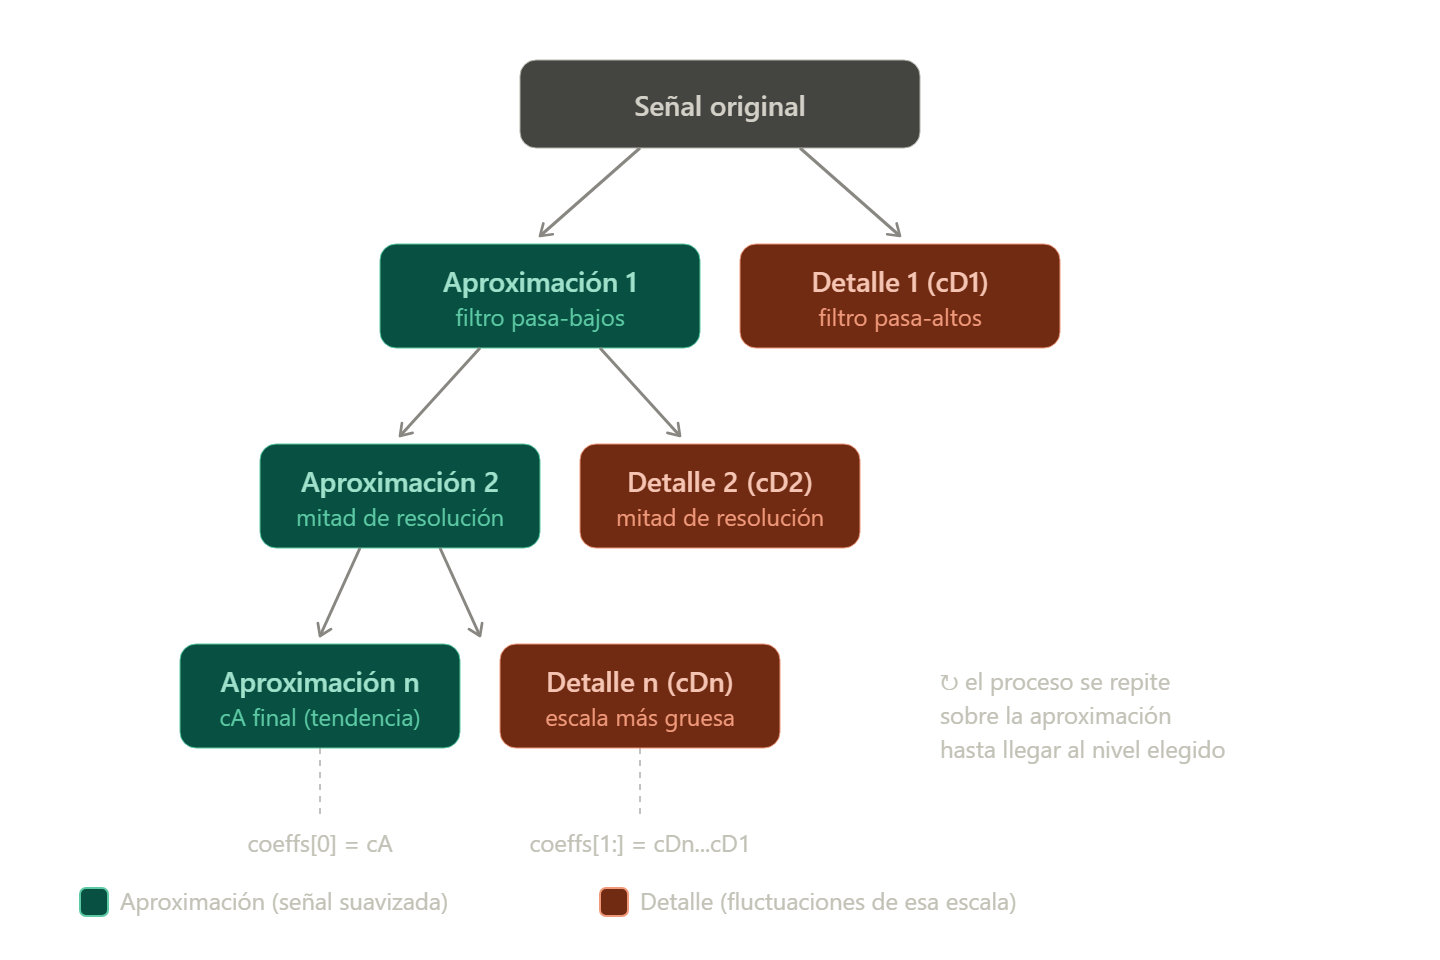

In [33]:
# Elegimos una wavelet madre. db4 (Daubechies 4) porque me pintó
wavelet = 'db4'

# Nivel máximo de descomposición permitido por el largo de la serie
# Recordemos que cada nivel de la piramide que estamos construyendo reduce la resolucion a la mitad
nivel_max = pywt.dwt_max_level(len(precios_vals), pywt.Wavelet(wavelet).dec_len)
print(f'Nivel máximo de descomposición posible: {nivel_max}')

# Elegimos un nivel razonable (no hace falta ir al máximo)
nivel = min(6, nivel_max)

# wavedec aplica el algoritmo piramidal de Mallat:
# separa la señal en 1 aproximación (cA) + "nivel" detalles (cD1...cDn)
coeffs = pywt.wavedec(precios_vals, wavelet, level=nivel)

# coeffs[0] = coeficientes de aproximación (tendencia más "gruesa")
# coeffs[1:] = coeficientes de detalle, de la escala más gruesa a la más fina
cA = coeffs[0]
cDs = coeffs[1:]

print(f'Cantidad de niveles de detalle: {len(cDs)}')
for i, cD in enumerate(cDs):
    print(f'  Detalle nivel {len(cDs)-i}: {len(cD)} coeficientes')

Nivel máximo de descomposición posible: 9
Cantidad de niveles de detalle: 6
  Detalle nivel 6: 73 coeficientes
  Detalle nivel 5: 140 coeficientes
  Detalle nivel 4: 274 coeficientes
  Detalle nivel 3: 541 coeficientes
  Detalle nivel 2: 1075 coeficientes
  Detalle nivel 1: 2143 coeficientes


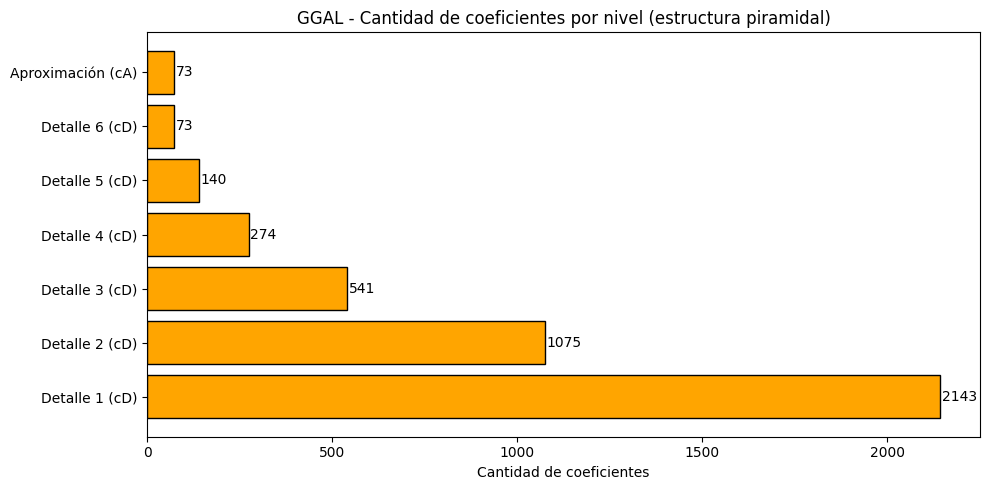

In [16]:
etiquetas = ['Aproximación (cA)'] + [f'Detalle {len(cDs)-i} (cD)' for i in range(len(cDs))]
tamaños = [len(cA)] + [len(cD) for cD in cDs]

plt.figure(figsize=(10, 5))
barras = plt.barh(etiquetas, tamaños, color='orange', edgecolor='black')
plt.gca().invert_yaxis()  # aproximación arriba, detalles finos abajo

for barra, tam in zip(barras, tamaños):
    plt.text(tam + 5, barra.get_y() + barra.get_height()/2, str(tam), va='center')

plt.title(f'{ticker} - Cantidad de coeficientes por nivel (estructura piramidal)')
plt.xlabel('Cantidad de coeficientes')
plt.tight_layout()
plt.show()

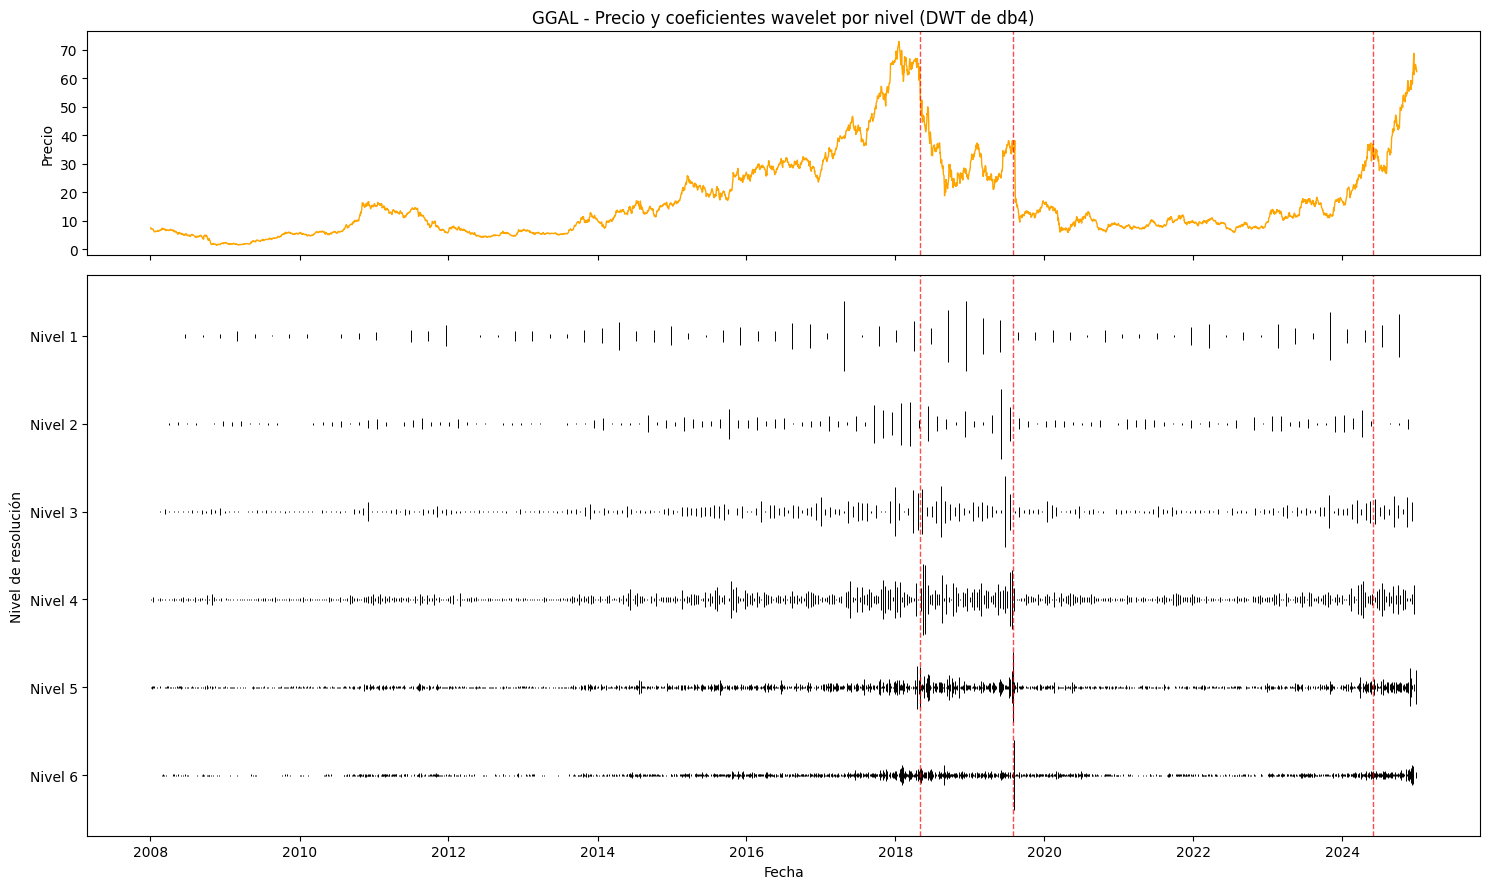

In [17]:
fig, (ax_precio, ax_scalo) = plt.subplots(
    2, 1, figsize=(15, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 2.5]}  
)

# Panel superior: precio de GGAL
ax_precio.plot(fechas, precios_vals, color='orange', linewidth=1)
ax_precio.set_ylabel('Precio')
ax_precio.set_title(f'{ticker} - Precio y coeficientes wavelet por nivel (DWT de {wavelet})')

# Panel inferior: scalogram 
n_niveles = len(cDs)
fecha_inicio = fechas[0]
fecha_fin = fechas[-1]

for i, cD in enumerate(cDs):
    fila_y = n_niveles - i

    posiciones_relativas = np.arange(len(cD)) / len(cD)
    posiciones_fecha = fecha_inicio + posiciones_relativas * (fecha_fin - fecha_inicio)

    magnitudes = np.abs(cD) / (np.abs(cD).max() + 1e-9)

    ax_scalo.vlines(posiciones_fecha, fila_y - magnitudes * 0.4, fila_y + magnitudes * 0.4,
                     color='black', linewidth=0.7)

ax_scalo.set_yticks(range(1, n_niveles + 1))
ax_scalo.set_yticklabels([f'Nivel {n_niveles - i}' for i in range(n_niveles)])
ax_scalo.set_xlabel('Fecha')
ax_scalo.set_ylabel('Nivel de resolución')

ax_scalo.xaxis.set_major_locator(mdates.YearLocator(2))
ax_scalo.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ---- Líneas verticales punteadas en las zonas de mayor concentración ----
# Identificadas visualmente en el scalogram: picos que atraviesan todos los niveles
fechas_clave = pd.to_datetime(['2018-05-01', '2019-08-01', '2024-06-01'])

for f in fechas_clave:
    ax_precio.axvline(x=f, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_scalo.axvline(x=f, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

El Escalograma logra identificar en qué momento y a qué escala ocurre un momento "importante" en la acción (mas concentracion y mas barritas).

Vemos 3 concentraciones importantes:
- **Mediados 2018:** Crisis cambiaria Argentina de 2018 (devaluacion abrupta del peso con Macri).
- **Mediadios 2019:** Incertidumbre política (Formula Fernandez-Fernandez gana las PASO).
- **Mediados 2024:** Fuerte revalorización del sector privado (Asume Milei la presidencia).

Reconstruimos cada componente por separado

In [18]:
def reconstruir_componente(coeffs, idx, wavelet):
    
    coeffs_zero = [np.zeros_like(c) for c in coeffs]
    coeffs_zero[idx] = coeffs[idx]
    return pywt.waverec(coeffs_zero, wavelet)[:len(precios_vals)]

# Componente de aproximación (tendencia de fondo, escala más gruesa)
aproximacion = reconstruir_componente(coeffs, 0, wavelet)

# Componentes de detalle (fluctuaciones en cada escala temporal)
detalles = [reconstruir_componente(coeffs, i+1, wavelet) for i in range(len(cDs))]

Precio original vs componente de aproximación

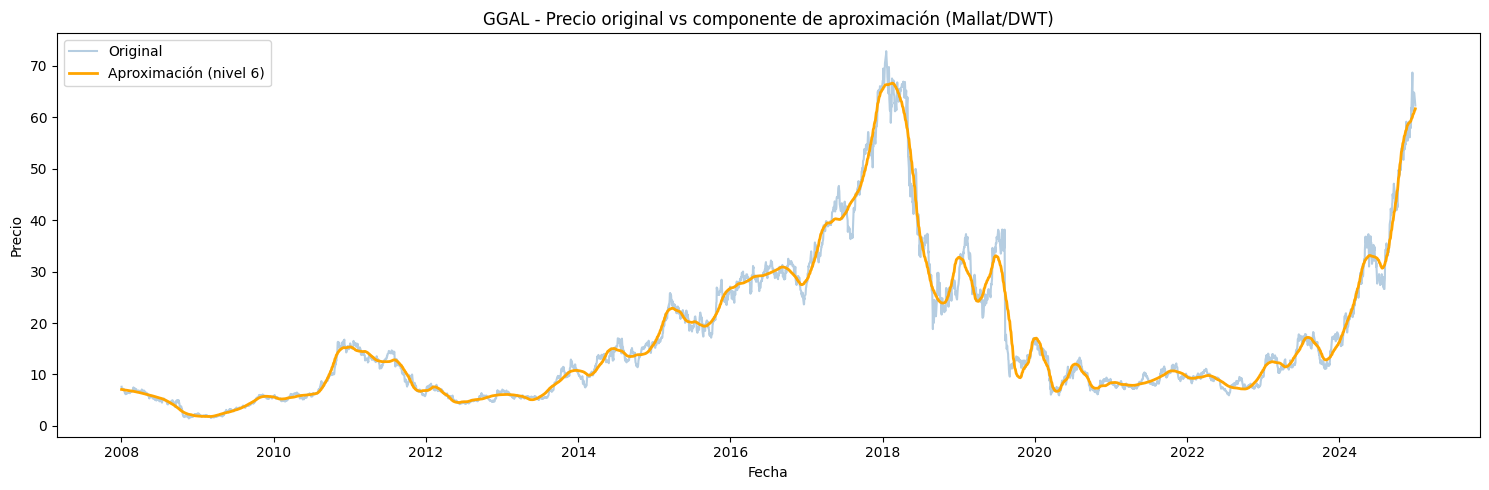

R² (varianza explicada): 0.9847


In [19]:
plt.figure(figsize=(15, 5))
plt.plot(fechas, precios_vals, color = 'steelblue', alpha=0.4, label='Original')
plt.plot(fechas, aproximacion, color='orange', linewidth=2, label=f'Aproximación (nivel {nivel})')
plt.title(f'{ticker} - Precio original vs componente de aproximación (Mallat/DWT)')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

# Error R²
error = precios_vals - aproximacion
r2 = 1 - (np.sum(error**2) / np.sum((precios_vals - precios_vals.mean())**2))  
print(f'R² (varianza explicada): {r2:.4f}')

Descomposición completa por niveles

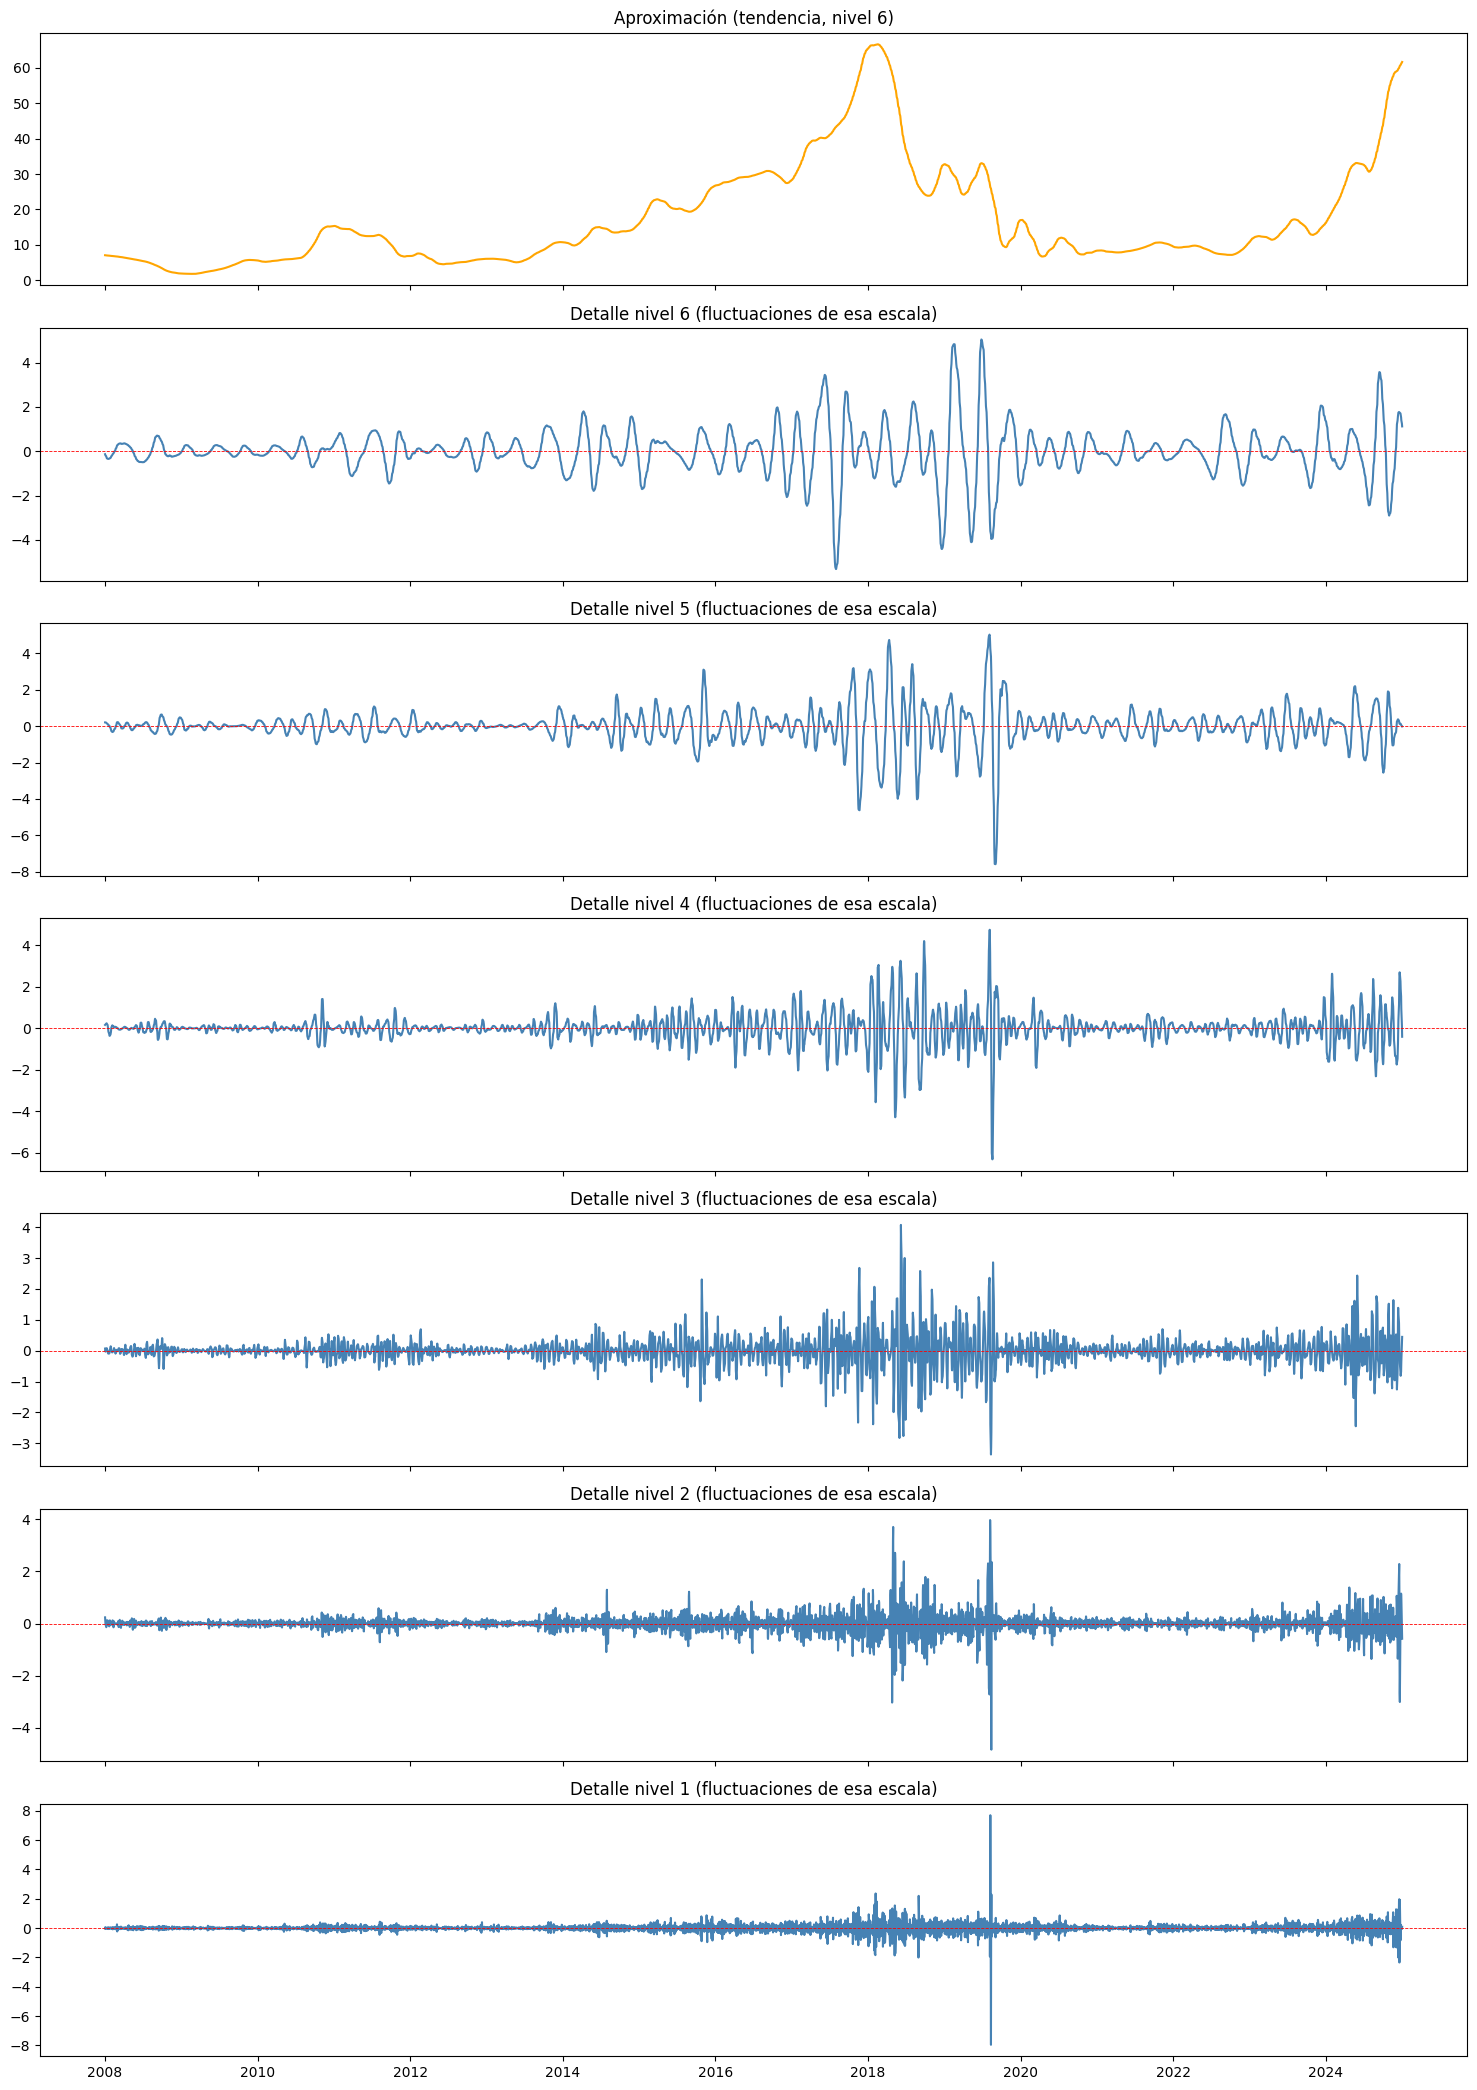

In [20]:
n_paneles = len(detalles) + 1
fig, axes = plt.subplots(n_paneles, 1, figsize=(15, 3 * n_paneles), sharex=True)

# Primer panel: aproximación (tendencia)
axes[0].plot(fechas, aproximacion, color='orange')
axes[0].set_title(f'Aproximación (tendencia, nivel {nivel})')

# Resto de paneles: detalles, de la escala más gruesa (más lenta) a la más fina (más rápida)
for i, det in enumerate(detalles):
    nivel_detalle = len(detalles) - i
    axes[i+1].plot(fechas, det, color='steelblue')
    axes[i+1].set_title(f'Detalle nivel {nivel_detalle} (fluctuaciones de esa escala)')
    axes[i+1].axhline(y=0, color='red', linestyle='--', linewidth=0.6)

plt.tight_layout()
plt.show()

Energia por escala. No agregamos la Aproximación porque contempla el 99% de la energía total.

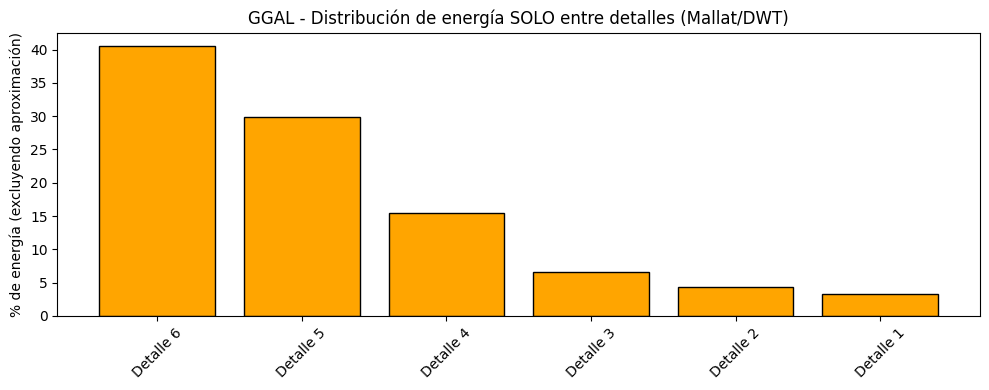

Detalle 6: 40.49%
Detalle 5: 29.90%
Detalle 4: 15.53%
Detalle 3: 6.57%
Detalle 2: 4.28%
Detalle 1: 3.23%


In [21]:
energias_detalle = [np.sum(cD ** 2) for cD in cDs]

energia_solo_detalles = sum(energias_detalle)
porcentajes_detalle = [100 * e / energia_solo_detalles for e in energias_detalle]

etiquetas_detalle = [f'Detalle {len(cDs)-i}' for i in range(len(cDs))]

plt.figure(figsize=(10, 4))
plt.bar(etiquetas_detalle, porcentajes_detalle, color='orange', edgecolor='black')
plt.title(f'{ticker} - Distribución de energía SOLO entre detalles (Mallat/DWT)')
plt.ylabel('% de energía (excluyendo aproximación)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for etiqueta, pct in zip(etiquetas_detalle, porcentajes_detalle):
    print(f'{etiqueta}: {pct:.2f}%')

Al excluir la tendencia, la energía decrece, mostrando que las fluctuaciones de GGAL son mayormente de mediano-largo plazo, no ruido de corto plazo.

Reconstruimos la señal conservando solo las escalas que superan un umbral mínimo de energía relativa y descartamos las escalas que aportan poco (equivalente wavelet a "eliminar ruido").

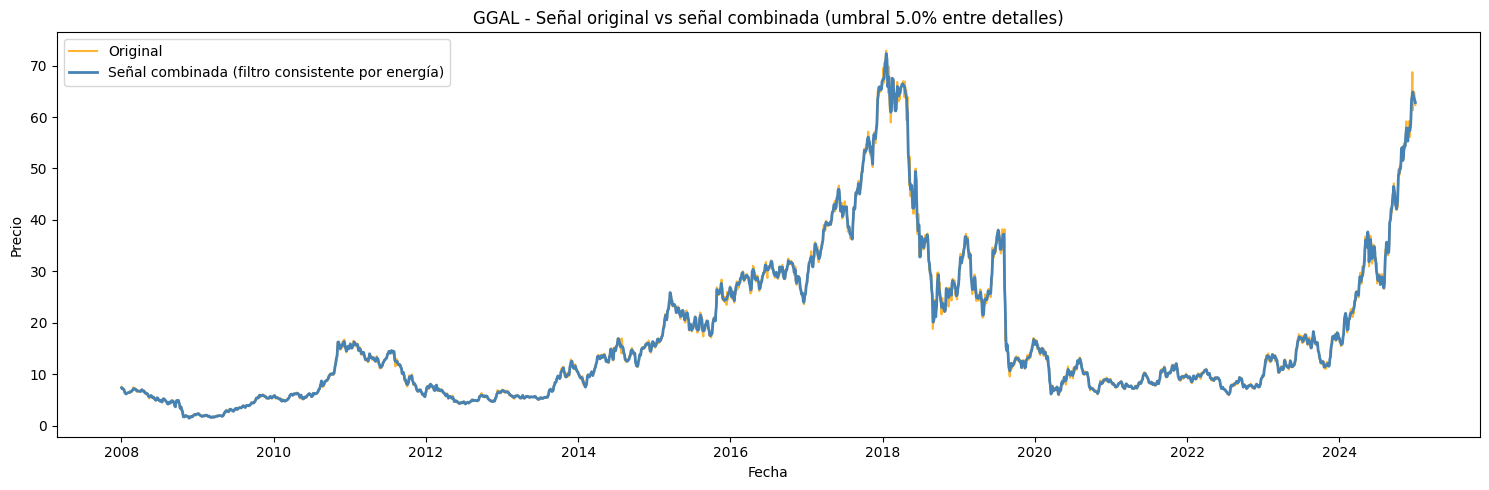

Niveles conservados:
  Aproximación: sí (siempre)
  Detalle 6: 40.49% -> conservado
  Detalle 5: 29.90% -> conservado
  Detalle 4: 15.53% -> conservado
  Detalle 3: 6.57% -> conservado
  Detalle 2: 4.28% -> descartado
  Detalle 1: 3.23% -> descartado
R² (varianza explicada): 0.9988


In [22]:
umbral_energia_pct = 5.0  # % minimo de energía entre detalles para conservar el nivel

coeffs_filtrados = [coeffs[0]]  # siempre conservamos la aproximación (tendencia)

for i, pct in enumerate(porcentajes_detalle):
    if pct < umbral_energia_pct:
        coeffs_filtrados.append(np.zeros_like(cDs[i]))
    else:
        coeffs_filtrados.append(cDs[i])

señal_combinada = pywt.waverec(coeffs_filtrados, wavelet)[:len(precios_vals)]

plt.figure(figsize=(15, 5))
plt.plot(fechas, precios_vals, alpha=0.8, label='Original', color='orange')
plt.plot(fechas, señal_combinada, color='steelblue', linewidth=2, label='Señal combinada (filtro consistente por energía)')
plt.title(f'{ticker} - Señal original vs señal combinada (umbral {umbral_energia_pct}% entre detalles)')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

print('Niveles conservados:')
print('  Aproximación: sí (siempre)')
for i, pct in enumerate(porcentajes_detalle):
    nivel_num = len(cDs) - i
    estado = 'conservado' if pct >= umbral_energia_pct else 'descartado'
    print(f'  Detalle {nivel_num}: {pct:.2f}% -> {estado}')


error = precios_vals - señal_combinada
r2 = 1 - (np.sum(error**2) / np.sum((precios_vals - precios_vals.mean())**2))  
print(f'R² (varianza explicada): {r2:.4f}')